# Load Packages and Data

In [1]:
import os
import sys
sys.path.append(os.getcwd())
sys.path.append(f"{os.getcwd()}/..")

from gp import GaussianProcess
import pandas as pd
import jax
import jax.numpy as jnp
import jax.random as jr
import jax.scipy as jsp
import numpy as np

import time
import matplotlib.pyplot as plt
import dill

In [2]:
y_train = jnp.load('../data/y_train.npy')
n = y_train.shape[0]

X_train = jnp.load('../data/X_train.npy')
y_train = y_train

obs_count = jnp.load('../data/obs_count.npy')

# y_mean = y_train.mean()
# y_std = y_train.std()
# y_train = (y_train - y_mean) / y_std

# Configure and Run GP

In [3]:
indoor_mask = X_train[:,2].astype(bool)
outdoor_mask = ~X_train[:,2].astype(bool)

indoor_mean = y_train[indoor_mask].mean()
outdoor_mean = y_train[outdoor_mask].mean()

def m(obs):
    return obs[2] * indoor_mean + (1 - obs[2]) * outdoor_mean
    
ls_xyz = jnp.array([0.2, 0.2, 0.1])
os_xyz = 10
ls_t = 0.05
os_t = 5

def K(obs1, obs2):
    d_xyz = (obs1[:3] - obs2[:3])**2
    d_t = (obs1[3] - obs2[3])**2
    return os_xyz * jnp.exp(- (d_xyz / ls_xyz**2).sum()) + \
        os_t * jnp.exp(- d_t / (2*ls_t**2))

In [5]:
GP = GaussianProcess(m, K)
GP.fit(X_train, y_train, obs_count)

In [6]:
start = time.time()
chain = GP.gibbs()
end = time.time()
print(f"Elapsed: {end - start}")

Elapsed: 4.380606412887573


In [7]:
indoor_vars = chain[1][:,:,1]
outdoor_vars = chain[1][:,:,0]

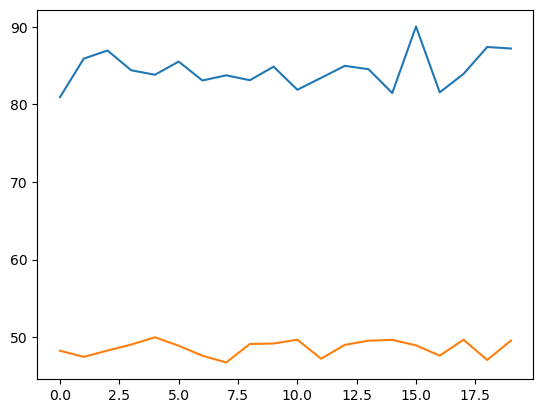

In [8]:
plt.plot(range(indoor_vars.shape[1]), indoor_vars[0])
plt.plot(range(outdoor_vars.shape[1]), outdoor_vars[0])
plt.show()

In [9]:
f_chains = chain[0][:,0:]
cov_chains = chain[1][:,0:]

# Predict on New Data

In [10]:
X_new = jnp.load('../data/X_test.npy')
X_new = X_new.at[:,3].set(100)
with open('../data/osm_context.pkl', 'rb') as f:
    osm_context = dill.load(f)
wlon_train, wlat_train = np.load('../data/world_train.npy').T
wlon_test, wlat_test = np.load('../data/world_test.npy').T

In [11]:
new_means, new_vars = GP.predict(X_new, cov_chains)

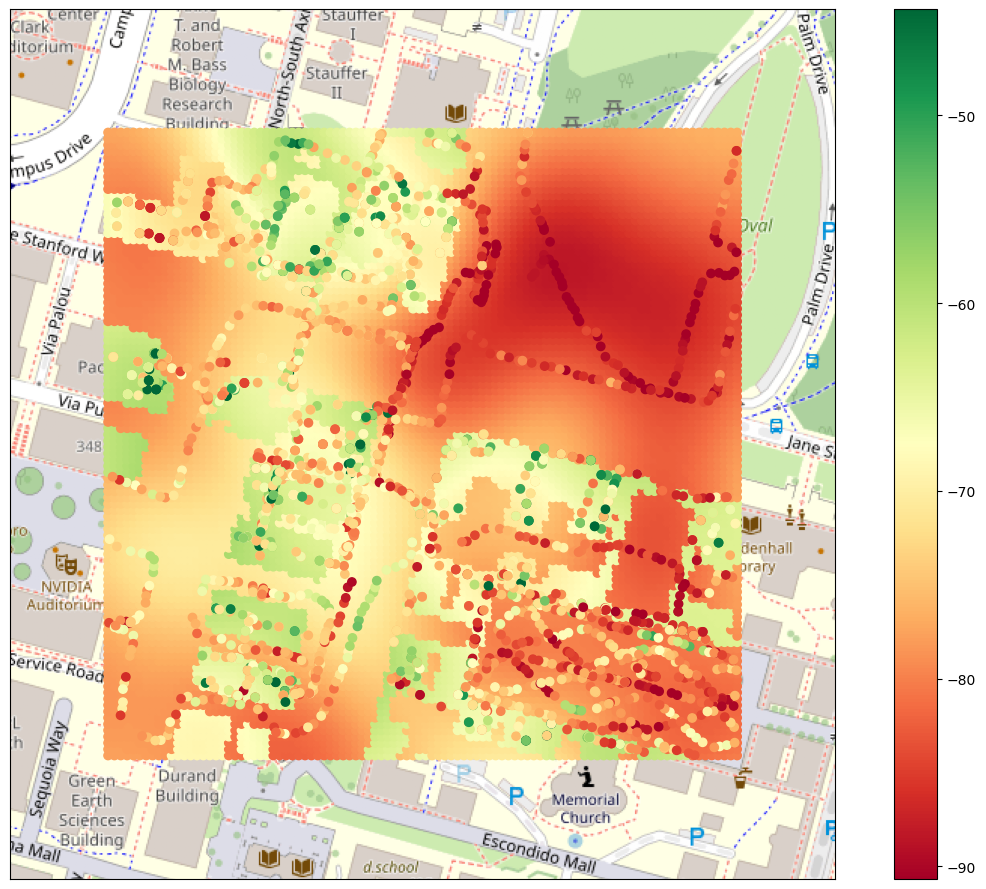

In [12]:
vmax = jnp.quantile(y_train, 0.975)
vmin = jnp.quantile(y_train, 0.025)

base_fig, base_ax, osm_metadata = osm_context.generate_base_axis(draw_buildings=False)

sc = base_ax.scatter(wlon_test, wlat_test, c=new_means.mean(axis=0), cmap="RdYlGn", vmin=vmin, vmax=vmax)

tr = base_ax.scatter(wlon_train, wlat_train, c=y_train, cmap="RdYlGn",
                vmin=vmin, vmax=vmax, alpha=1)
plt.ticklabel_format(style='plain', axis='both', useOffset=False)

plt.colorbar(tr)
plt.tight_layout()